In [11]:
%cd /content
!git clone https://github.com/amartinsmg/classification-of-medical-images-using-cnn.git
%cd /content/classification-of-medical-images-using-cnn

/content
fatal: destination path 'classification-of-medical-images-using-cnn' already exists and is not an empty directory.
/content/classification-of-medical-images-using-cnn


In [12]:
from google.colab import drive

drive.mount("/content/drive")

BASE_PATH = "/content/drive/MyDrive/classification-of-medical-images-using-cnn/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
experiment_names = ["efficientnet-baseline", "efficientnet-final-1",
                  "densenet-baseline", "densenet-final-2",
                  "resnet-baseline", "resnet-final-1"]

COMPARISON_PATH = "comparisons/07-baseline-vs-final"
RESULT_PATH = BASE_PATH + "results"
SAVE_DIR = BASE_PATH + COMPARISON_PATH

In [14]:
from src.analyses import load_experiments

experiments = load_experiments(RESULT_PATH, experiment_names)

In [15]:
from src.analyses import metrics_table
from IPython.display import display

metrics = metrics_table(experiments)
display(metrics)

,accuracy-mean,accuracy-std,precision-mean,precision-std,recall-mean,recall-std,f1-score-mean,f1-score-std,specificity-mean,specificity-std,auc-roc-mean,auc-roc-std
experiment,,,,,,,,,,,,
efficientnet-baseline,0.866987,0.022664,0.848382,0.044925,0.964103,0.025726,0.901138,0.013308,0.705128,0.102979,0.961047,0.002615
efficientnet-final-1,0.911325,0.006044,0.947609,0.007872,0.908547,0.016922,0.927508,0.005720,0.915954,0.014527,0.969923,0.001793
densenet-baseline,0.855769,0.019275,0.831175,0.031108,0.968376,0.017433,0.893862,0.010904,0.668091,0.080355,0.956991,0.001435
densenet-final-2,0.897436,0.002617,0.930336,0.017147,0.904274,0.016792,0.916808,0.001657,0.886040,0.032421,0.956323,0.000575
resnet-baseline,0.879808,0.024234,0.885167,0.056200,0.936752,0.042306,0.907570,0.013514,0.784900,0.129684,0.954208,0.005962
resnet-final-1,0.905449,0.002266,0.945295,0.002470,0.900855,0.001209,0.922539,0.001810,0.913105,0.004029,0.963566,0.003803


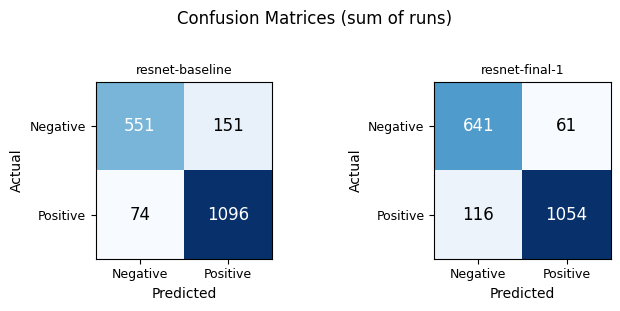

In [16]:
from src.analyses import plot_confusion_matrices
import matplotlib.pyplot as plt

resnet_exps = [exp for exp in experiments if exp.get("name").startswith("resnet")]

fig = plot_confusion_matrices(resnet_exps)

plt.show()

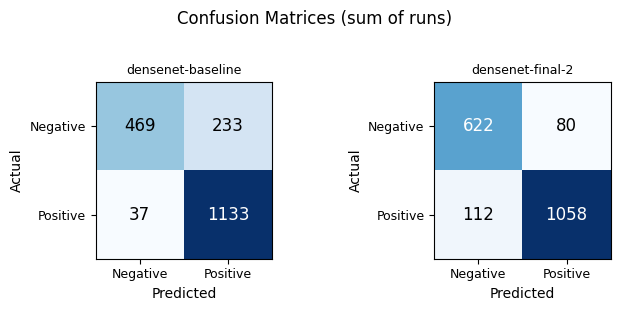

In [17]:
densenet_exps = [exp for exp in experiments if exp.get("name").startswith("densenet")]

fig = plot_confusion_matrices(densenet_exps)

plt.show()

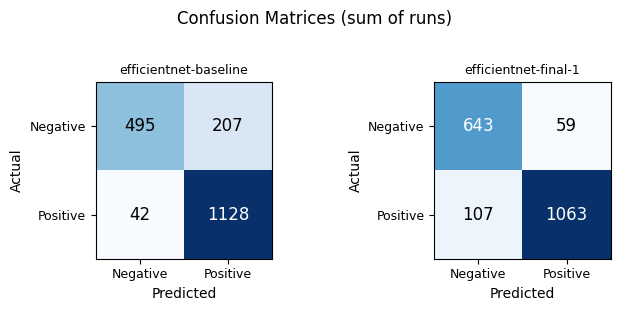

In [18]:
efficientnet_exps = [exp for exp in experiments if exp.get("name").startswith("efficientnet")]

fig = plot_confusion_matrices(efficientnet_exps)

plt.show()

In [21]:
from src.analyses import full_comparison

_ = full_comparison(
  base_result_dir=RESULT_PATH,
  experiment_names=experiment_names,
  show_plot=False,
  save_dir=SAVE_DIR,
  separe_archs=True
)


Results saved in /content/drive/MyDrive/classification-of-medical-images-using-cnn/comparisons/07-baseline-vs-final


Faz upload da tabela e dos gráficos das comparações para o DagsHub

In [22]:
%pip install -q dvc dagshub

import dagshub
from google.colab import userdata

dagshub.auth.add_app_token(token=userdata.get("DAGSHUB_TOKEN"))


dagshub.upload_files(
    "amartinsmg/classification-of-medical-images-using-cnn",
    local_path=SAVE_DIR,
    remote_path=COMPARISON_PATH,
)

Accessing as amartinsmg

Output()

Directory upload complete, uploaded 13 files to 
https://dagshub.com/amartinsmg/classification-of-medical-images-using-cnn/src/main/comparisons%2F07-baseline-vs-fin
al